In [12]:
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [13]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [14]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

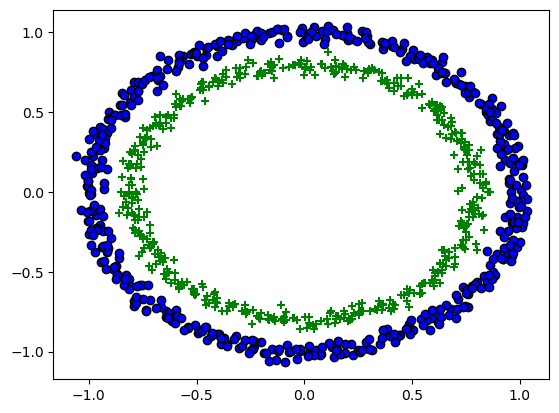

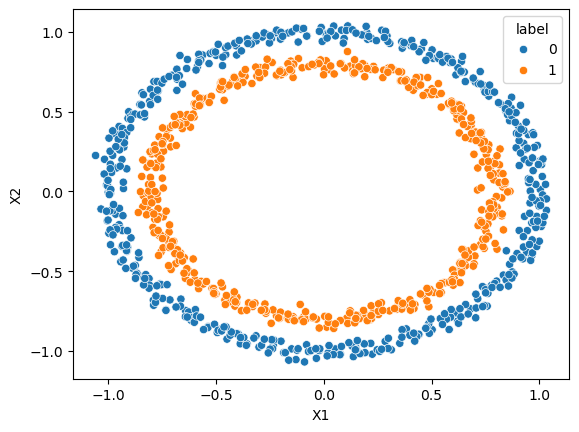

In [15]:
import matplotlib.pyplot as plt
plt.scatter(circles[circles['label'] == 0]['X1'], circles[circles['label'] == 0]['X2'], color='blue', edgecolors='black')
plt.scatter(circles[circles['label'] == 1]['X1'], circles[circles['label'] == 1]['X2'], color='green', marker='+')
plt.show()

import seaborn as sns
sns.scatterplot(circles, x = 'X1', y = 'X2', hue = 'label')
plt.show()

In [16]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split
# Split dataset into train/test sets
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

# Make device
# Non MacOS: device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"    


In [17]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device

In [18]:
class SimpleModel(nn.Module):
    def __init__(self, in_feature):
        super().__init__()
        self.fc_1 = nn.Linear(in_feature, out_features=10)
        self.fc_2 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        temp = self.fc_2(self.relu(self.fc_1(x)))
        return self.sigmoid(temp.squeeze())

In [19]:
in_feature = X_train.shape[1]
model = SimpleModel(in_feature).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [20]:
# Training model
torch.manual_seed(42)
num_epochs = 3001

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(num_epochs):
    model.train()
    y_logit = model(X_train) #Note this is Gradient Descent on 'stochastic gradient descent'
    y_predict = torch.round(y_logit)

    train_loss = loss_fn(y_logit, y_train)

    # Compute accuracy
    correct = torch.eq(y_predict, y_train).sum().item()
    train_acc = (correct / len(y_predict)) * 100

    # Update step
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Testing
    if epoch % 50 == 0:
        model.eval()
        with torch.inference_mode():
            y_test_logit = model(X_test)
            y_test_predict = torch.round(y_test_logit)
            test_loss = loss_fn(y_test_logit, y_test)
            correct = torch.eq(y_test_predict, y_test).sum().item()
            test_acc = (correct / len(y_test_predict)) * 100

        print(f"Epoch: {epoch} | Loss: {train_loss:.5f}, Accuracy: {train_acc:.2f}% | "
              f"Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 0.69711, Accuracy: 53.00% | Test loss: 0.69721, Test accuracy: 54.50
Epoch: 50 | Loss: 0.69231, Accuracy: 56.75% | Test loss: 0.69155, Test accuracy: 54.50
Epoch: 100 | Loss: 0.68978, Accuracy: 54.25% | Test loss: 0.68859, Test accuracy: 53.00
Epoch: 150 | Loss: 0.68750, Accuracy: 54.25% | Test loss: 0.68605, Test accuracy: 55.00
Epoch: 200 | Loss: 0.68533, Accuracy: 55.25% | Test loss: 0.68368, Test accuracy: 57.50
Epoch: 250 | Loss: 0.68325, Accuracy: 55.50% | Test loss: 0.68136, Test accuracy: 59.00
Epoch: 300 | Loss: 0.68120, Accuracy: 55.38% | Test loss: 0.67906, Test accuracy: 57.50
Epoch: 350 | Loss: 0.67911, Accuracy: 55.62% | Test loss: 0.67672, Test accuracy: 57.50
Epoch: 400 | Loss: 0.67702, Accuracy: 56.25% | Test loss: 0.67437, Test accuracy: 58.50
Epoch: 450 | Loss: 0.67487, Accuracy: 57.12% | Test loss: 0.67199, Test accuracy: 59.00
Epoch: 500 | Loss: 0.67267, Accuracy: 57.88% | Test loss: 0.66956, Test accuracy: 59.50
Epoch: 550 | Loss: 0.67039, Accurac

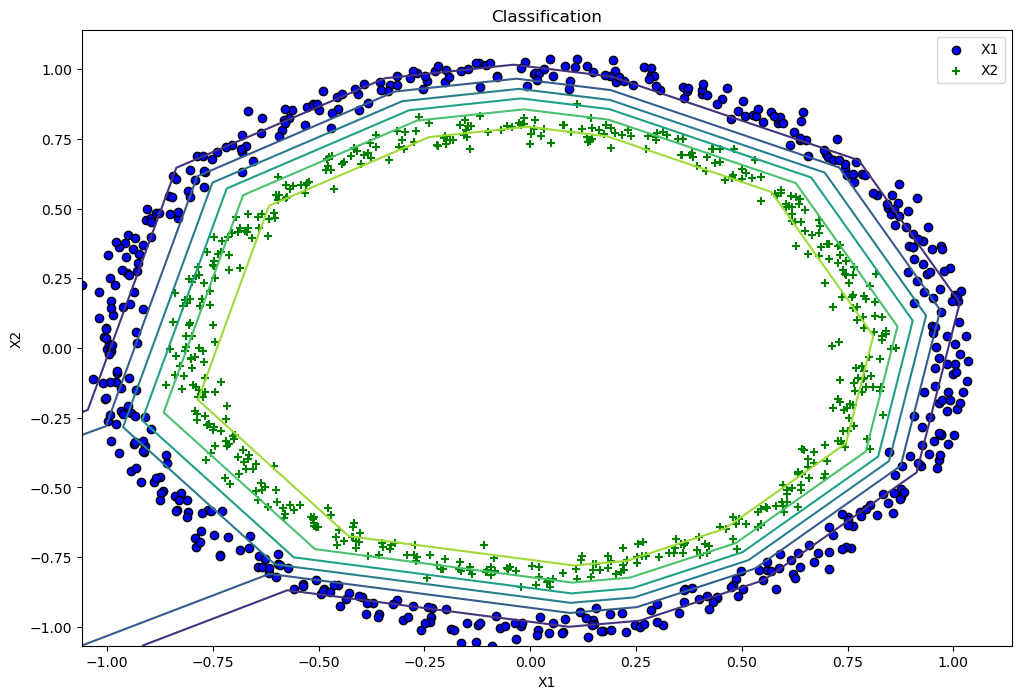

In [22]:
import numpy as np
# Plot results
col1 = 'X1'
col2 = 'X2'
min_ex1 = circles[col1].min()
max_ex1 = circles[col1].max()

min_ex2 = circles[col2].min()
max_ex2 = circles[col2].max()

arange_step = 0.001

xx, yy = np.meshgrid(np.arange(min_ex1, max_ex1, arange_step),
                     np.arange(min_ex2, max_ex2, arange_step))
grid_data = np.c_[xx.ravel(), yy.ravel()] # Concatenates 'column-wise'
grid_data = torch.from_numpy(grid_data).type(torch.float).to(device)
model.eval()
with torch.inference_mode():
    y_logit = model(grid_data)
    #y_predict = (y_logit>0.5).cpu().numpy()
    y_predict = (y_logit).cpu().numpy()

preds = y_predict.reshape(xx.shape)
fig = plt.figure(figsize=(12, 8))
plt.scatter(circles[circles['label'] == 0][col1], circles[circles['label'] == 0][col2],
            label='X1', color='blue', edgecolor='black')
plt.scatter(circles[circles['label'] == 1][col1], circles[circles['label'] == 1][col2],
            label='X2', marker='+', color='green')
plt.contour(xx, yy, preds)
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='upper right')
plt.title('Classification')
plt.show()

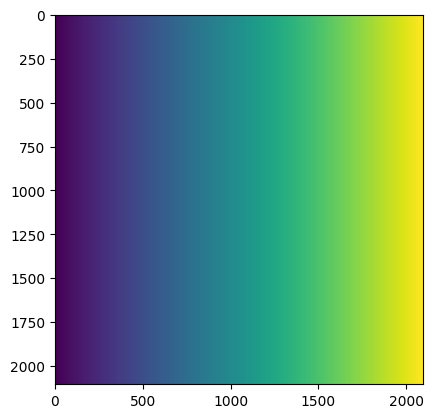

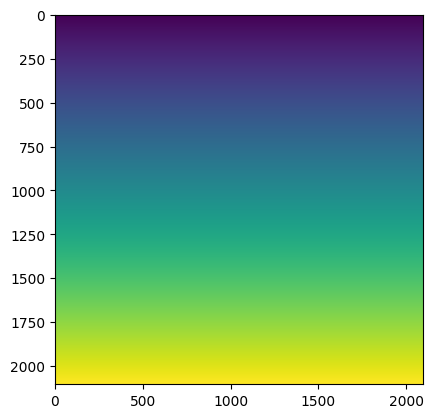

(2104, 2094) (4405776,)


In [14]:
plt.imshow(xx)
plt.show()
plt.imshow(yy)
plt.show()



In [15]:
print(xx.shape,xx.ravel().shape)

(2104, 2094) (4405776,)


In [10]:
#plt.scatter(xx, yy, c=preds)
#plt.show()

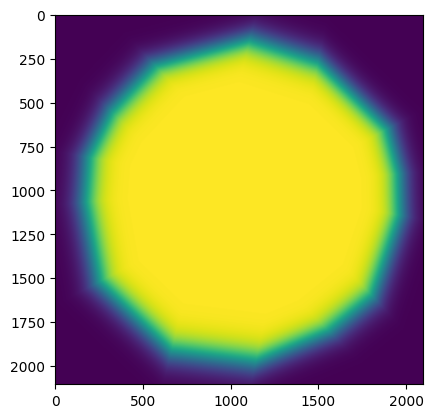

In [17]:
#plt.imshow(preds)
#plt.contour(xx, yy, preds)
#plt.show()